## Mismatch Score

### Mismatch Proxy

Directly computing the distance between description and review embeddings — for instance via cosine similarity — captures only the symmetric magnitude of semantic divergence, without distinguishing the direction of mismatch. However, the distinction between over-description and under-description is central to our research question, and a directionality-preserving formulation is therefore necessary. To this end, we leverage user ratings as a supervisory anchor. A rating represents the user's holistic judgment of their actual product experience, and as such encodes a grounded signal of realized product quality. The product description, by contrast, encodes anticipated quality as projected by the seller. The systematic difference in how well each modality predicts the rating thus serves as a natural proxy for the direction and magnitude of the gap between expectation and experience — which is precisely the mismatch we seek to quantify. Crucially, because both embedding spaces are mapped to the same rating target, this formulation yields a unified and directly comparable mismatch signal regardless of the underlying representational space, whether GloVe-based or the data-driven 10-dimensional semantic space.

We define a **rating-anchored mismatch proxy** to operationalize the directional divergence between product descriptions and reviews. Specifically, we train two separate regressors mapping description embeddings and review embeddings respectively to user ratings. The mismatch score for item i is defined as $M_i = \hat{y}_i^{desc} - \hat{y}_i^{rev}$​, where positive values indicate over-description (the description implies higher quality than the review reflects) and negative values indicate under-description. This formulation treats user rating as a shared anchor that projects both modalities into a common evaluative space, enabling directional comparison across heterogeneous embedding representations.

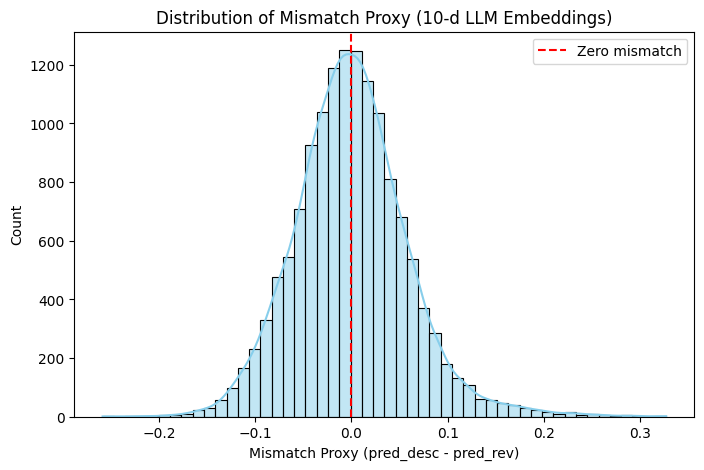

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example for llm (10-d) embeddings
df = pd.read_csv("llm_mismatch_score.csv")

plt.figure(figsize=(8,5))
sns.histplot(df['mismatch_proxy'], bins=50, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--', label='Zero mismatch')
plt.xlabel("Mismatch Proxy (pred_desc - pred_rev)")
plt.ylabel("Count")
plt.title("Distribution of Mismatch Proxy (10-d LLM Embeddings)")
plt.legend()
plt.show()


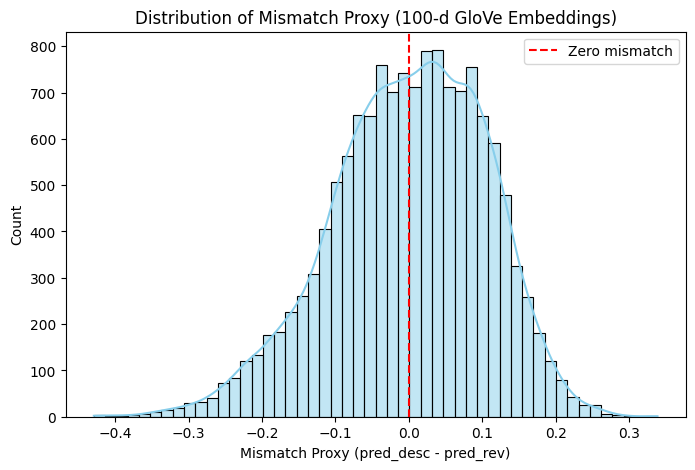

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example for glove (100-d) embeddings
df = pd.read_csv("baseline_mismatch_score.csv")

plt.figure(figsize=(8,5))
sns.histplot(df['mismatch_proxy'], bins=50, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--', label='Zero mismatch')
plt.xlabel("Mismatch Proxy (pred_desc - pred_rev)")
plt.ylabel("Count")
plt.title("Distribution of Mismatch Proxy (100-d GloVe Embeddings)")
plt.legend()
plt.show()


We observed that a positive mismatch proxy (mismatch_proxy > 0) does not necessarily correspond to cases where users give low ratings despite an overly positive description. Instead, it reflects instances where, according to the model, the description implies a higher expected rating than the review does. In other words, the proxy measures the relative discrepancy as learned by the embeddings, not the raw user dissatisfaction.

To identify the more traditional “over-promise leading to low ratings” cases, we would need to combine the mismatch proxy with a filter on actual ratings, for example selecting only rows with rating < 4.0. This ensures that the proxy highlights situations where the description oversells the product and the user experience is genuinely lower.

### Mismatch Score

It is worth noting that this proxy measure captures mismatch as reflected in user satisfaction rather than pure semantic divergence. Cases where description and review emphasize different product aspects but converge on similar satisfaction levels may be underrepresented by this metric. We therefore complement the main experiment with a dimension-level analysis on the 10-dimensional semantic space, which directly quantifies per-dimension divergence independent of rating supervision.

In [3]:
import statsmodels.api as sm

output_student_csv = "llm_mismatch_score.csv"
df = pd.read_csv(output_student_csv)

# -----------------------------
# 3. Regression: rating ~ mover + munder
# -----------------------------
X = df[['mover', 'munder']]
X = sm.add_constant(X)  # add intercept
y = df['rating']


model = sm.OLS(y, X).fit()
print("=== Regression Results: rating ~ mover + munder ===")
print(model.summary())

=== Regression Results: rating ~ mover + munder ===
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     262.3
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          1.45e-112
Time:                        17:50:56   Log-Likelihood:                 7244.1
No. Observations:               13950   AIC:                        -1.448e+04
Df Residuals:                   13947   BIC:                        -1.446e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
